# Diabetes Data Exploration

In [1]:
# Import libraries
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# Load databset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path)

In [3]:
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (11744, 9)


,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display Columns of Interest with Descriptions
columns_of_interest = {
    "SEQN": "Respondent sequence number",
    "DIQ010": "Doctor told you have diabetes",
    "DID040": "Age when first told you had diabetes",
    "DIQ160": "Ever told you have prediabetes",
    "DIQ180": "Had blood tested past three years",
    "DIQ050": "Taking insulin now",
    "DID060": "How long taking insulin",
    "DIQ060U": "Unit of measure (month/year)",
    "DIQ070": "Take diabetic pills to lower blood sugar"
}

df = df[list(columns_of_interest.keys())]
df.rename(columns=columns_of_interest, inplace=True)
df.head()

,Respondent sequence number,Doctor told you have diabetes,Age when first told you had diabetes,Ever told you have prediabetes,Had blood tested past three years,Taking insulin now,How long taking insulin,Unit of measure (month/year),Take diabetic pills to lower blood sugar
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Frequency Tables
for col in df.columns[1:]:
    print(f"\n=== Frequency for {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())


=== Frequency for Doctor told you have diabetes ===
Doctor told you have diabetes
1.0     1081
2.0    10371
3.0      284
9.0        4
NaN        4
Name: count, dtype: int64

=== Frequency for Age when first told you had diabetes ===
Age when first told you had diabetes
1.0          1
5.0          1
6.0          2
7.0          3
8.0          4
         ...  
78.0         3
79.0         2
80.0         7
999.0       24
NaN      10663
Name: count, Length: 77, dtype: int64

=== Frequency for Ever told you have prediabetes ===
Ever told you have prediabetes
1.0     918
2.0    7089
9.0      15
NaN    3722
Name: count, dtype: int64

=== Frequency for Had blood tested past three years ===
Had blood tested past three years
1.0    3370
2.0    4667
7.0       2
9.0     265
NaN    3440
Name: count, dtype: int64

=== Frequency for Taking insulin now ===
Taking insulin now
1.0      344
2.0      737
NaN    10663
Name: count, dtype: int64

=== Frequency for How long taking insulin ===
How long taking i

In [6]:
# Missing Values Summary
print("\nMissing Values Summary:")
print(df.isna().sum())


Missing Values Summary:
Respondent sequence number                      0
Doctor told you have diabetes                   4
Age when first told you had diabetes        10663
Ever told you have prediabetes               3722
Had blood tested past three years            3440
Taking insulin now                          10663
How long taking insulin                     11401
Unit of measure (month/year)                11412
Take diabetic pills to lower blood sugar     9463
dtype: int64


In [7]:
def mapping_status(data, mapping):
    labels = []
    for key in mapping:
        count_val = data.get(key, 0)
        labels.append(f"{mapping[key]}\n({count_val})")
    return (list(mapping.keys()), labels)

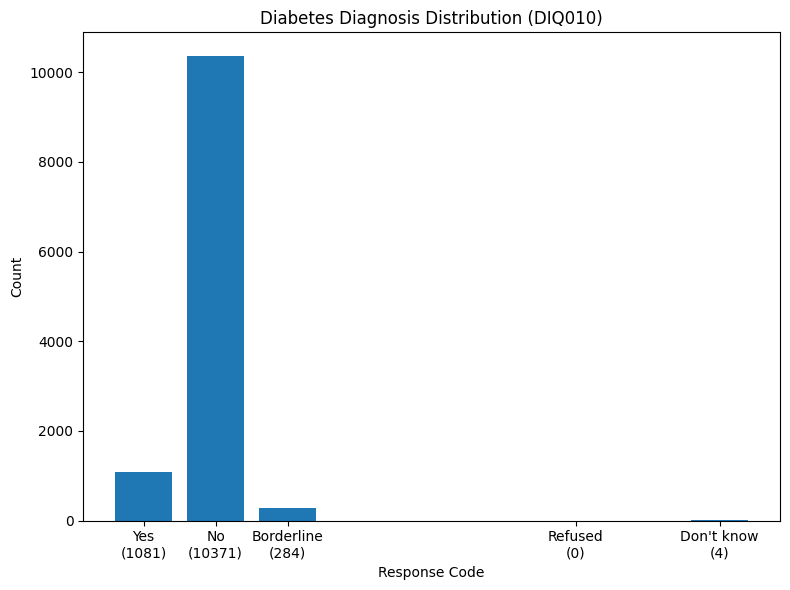

In [8]:
# Visualizing Diabetes Diagnosis Distribution
counts = df['Doctor told you have diabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}

# Create a bar plot using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetes Diagnosis Distribution (DIQ010)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/iabetes_diagnosis_distribution.png")
plt.show()

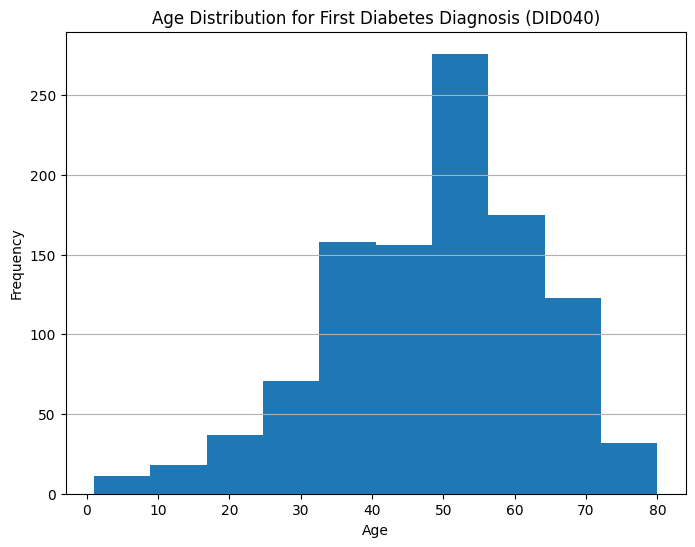

In [9]:
# Graph for Age when first told you had diabetes
age_data = df['Age when first told you had diabetes'].dropna()
age_data_clean = age_data[(age_data >= 1) & (age_data <= 81)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(age_data_clean)
plt.title('Age Distribution for First Diabetes Diagnosis (DID040)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/age_distribution_diabetes_diagnosis.png")
plt.show()

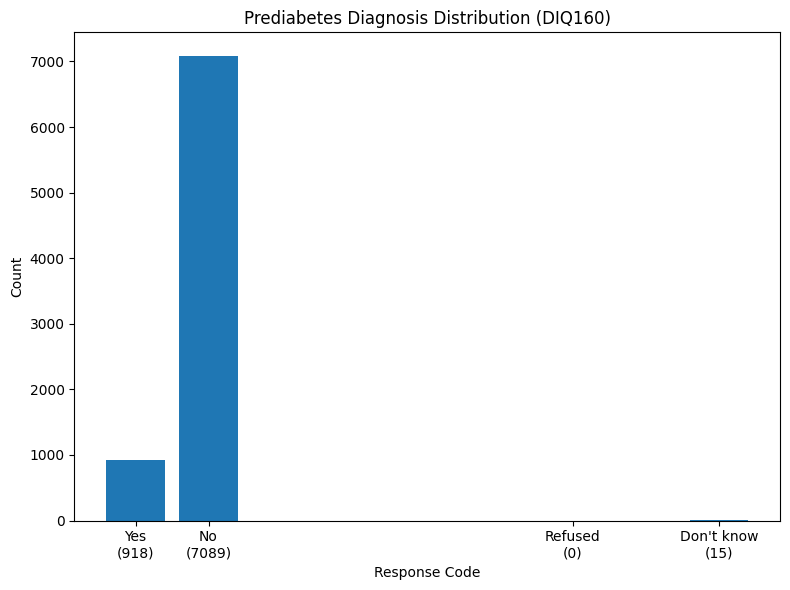

In [10]:
# Graph for Ever told you have prediabetes
counts = df['Ever told you have prediabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Prediabetes Diagnosis Distribution (DIQ160)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/prediabetes_diagnosis_distribution.png")
plt.show()

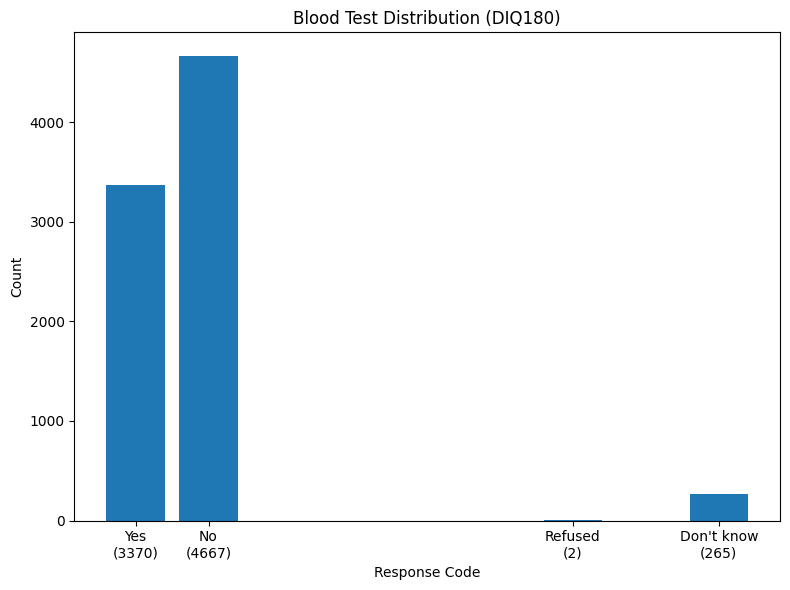

In [11]:
# Graph for Had blood tested past three years
counts = df['Had blood tested past three years'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Blood Test Distribution (DIQ180)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/blood_test_distribution.png")
plt.show()

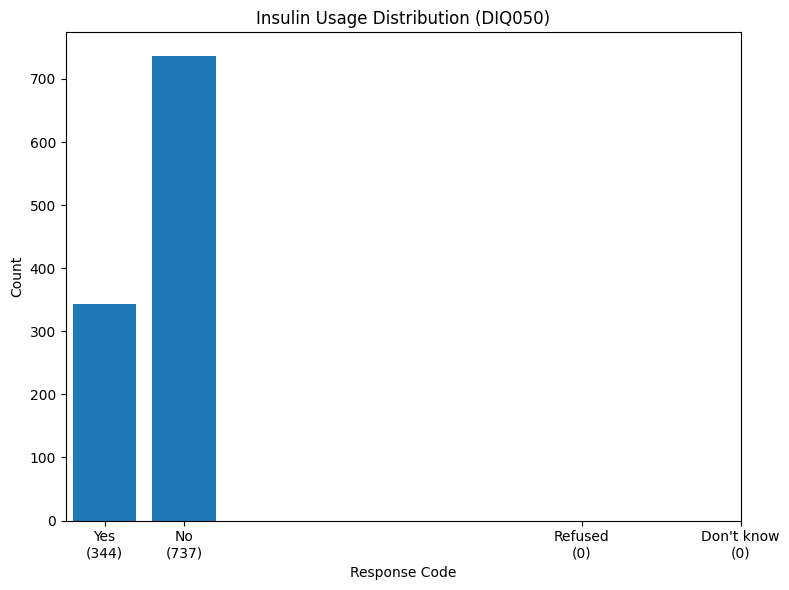

In [12]:
# Graph for Taking insulin now
counts = df['Taking insulin now'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Insulin Usage Distribution (DIQ050)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/insulin_usage_distribution.png")
plt.show()

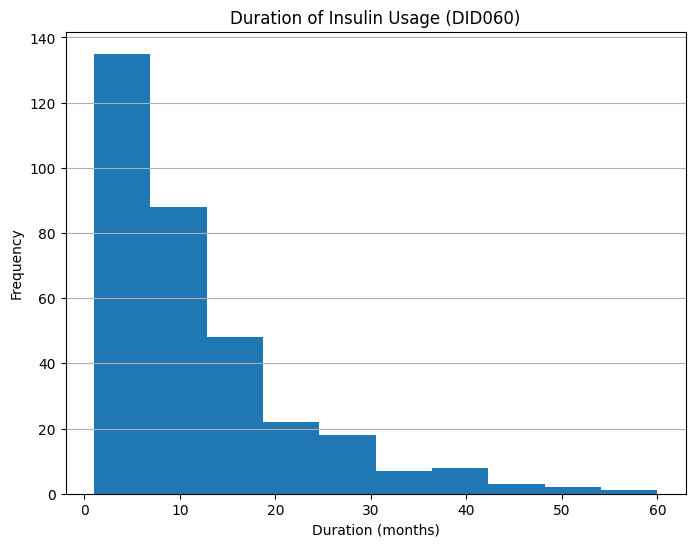

In [13]:
# Graph for How long taking insulin
insulin_duration = df['How long taking insulin'].dropna()
insulin_duration_clean = insulin_duration[(insulin_duration >= 1) & (insulin_duration <= 61)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(insulin_duration_clean)
plt.title('Duration of Insulin Usage (DID060)')
plt.xlabel('Duration (months)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/insulin_duration_distribution.png")
plt.show()

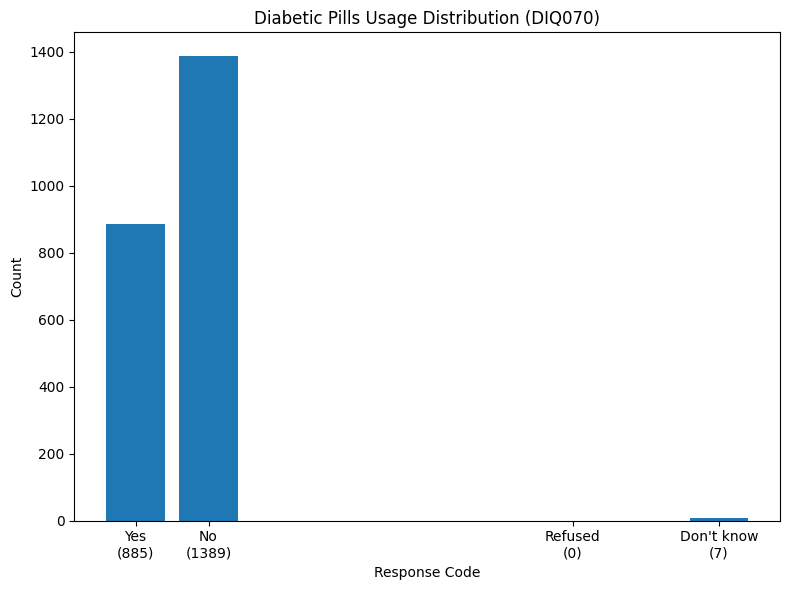

In [14]:
# Graph for Take diabetic pills to lower blood sugar
counts = df['Take diabetic pills to lower blood sugar'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetic Pills Usage Distribution (DIQ070)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/diabetic_pills_distribution.png")
plt.show()

In [15]:
# Save Cleaned Subset
df.to_csv("cleaned/diabetes_cleaned_subset.csv", index=False)

## Making Connections, Yippeeeeee

In [16]:
# code for combining all of the datasets into one

# import diabetes dataset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path, encoding='cp1252')

# goes through all other files and merges them into the dataframe
dir = 'all_data'
ind = 0
for file in os.scandir(dir):
    if file.is_file():
        print(file)
        ind += 1
        newdf, meta = pyreadstat.read_xport(file, encoding='cp1252')
        df = df.merge(newdf, on="SEQN", how="left", copy=False, suffixes=[f'_x{ind}', f'_y{ind}'])

# create csv from combined dataframe
print(df.head())
df.to_csv('all_data.csv', index=False)

<DirEntry 'UCPREG_L.xpt'>
<DirEntry 'RXQ_RX_L.xpt'>
<DirEntry 'HSCRP_L.xpt'>
<DirEntry 'HEQ_L.xpt'>
<DirEntry 'OHQ_L.xpt'>
<DirEntry 'RXQASA_L.xpt'>
<DirEntry 'HIQ_L.xpt'>
<DirEntry 'LUX_L.xpt'>
<DirEntry 'KIQ_U_L.xpt'>
<DirEntry 'HSQ_L.xpt'>
<DirEntry 'FOLFMS_L.xpt'>
<DirEntry 'DBQ_L.xpt'>
<DirEntry 'RHQ_L.xpt'>
<DirEntry 'CBC_L.xpt'>
<DirEntry 'IMQ_L.xpt'>
<DirEntry 'HOQ_L.xpt'>
<DirEntry 'FNQ_L.xpt'>
<DirEntry 'ACQ_L.xpt'>
<DirEntry 'TST_L.xpt'>
<DirEntry 'DPQ_L.xpt'>
<DirEntry 'SLQ_L.xpt'>
<DirEntry 'GLU_L.xpt'>
<DirEntry 'SMQRTU_L.xpt'>
<DirEntry 'AUQ_L.xpt'>
<DirEntry 'AGP_L.xpt'>
<DirEntry 'BPXO_L.xpt'>
<DirEntry 'HUQ_L.xpt'>
<DirEntry 'SMQFAM_L.xpt'>
<DirEntry 'VID_L.xpt'>
<DirEntry 'FOLATE_L.xpt'>
<DirEntry 'PUQMEC_L.xpt'>
<DirEntry 'PBCD_L.xpt'>
<DirEntry 'DEMO_L.xpt'>
<DirEntry 'ECQ_L.xpt'>
<DirEntry 'BMX_L.xpt'>
<DirEntry 'HDL_L.xpt'>
<DirEntry 'BAX_L.xpt'>
<DirEntry 'TCHOL_L.xpt'>
<DirEntry 'PAQ_L.xpt'>
<DirEntry 'PAQY_L.xpt'>
<DirEntry 'FERTIN_L.xpt'>
<DirEntry 'MCQ_L.xpt

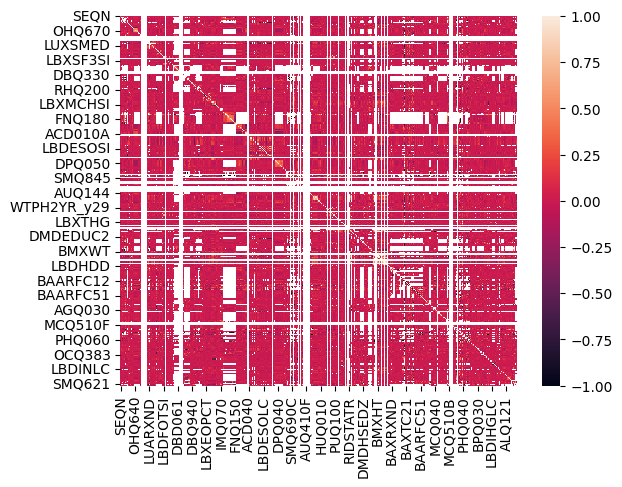

In [17]:
# import csv
df = pd.read_csv('all_data.csv')

# making correlation graph - only include numeric columns
corrmat = df.corr(numeric_only=True)
round(corrmat, 2)
sns.heatmap(corrmat)
plt.show()

In [18]:
# gets lists of correlations to DIQ010 (diagnosed w/ diabetes) and the corresponding codes
correlations = corrmat['DIQ010'].dropna().tolist()[2:]
codes = corrmat['DIQ010'].dropna().keys().tolist()[2:]

print(correlations)
print(codes)

[0.003616958110293217, -0.04779448131664248, 0.3985192707973136, -0.00794875371535926, 0.16368280101467603, -0.2860426996409845, 0.032052361243881396, -0.04158646216629765, 0.029610757288416573, -0.0020433295609305012, -0.13506303489494367, 0.05015570321216195, 0.08766841405021092, 0.05140204685652878, 0.06138888469260825, 0.07550990549116611, 0.04489236254740253, 0.1337395622957982, 0.05479913207131866, 0.04713808999898802, 0.016694218447181986, 0.05445053789162582, -0.0013128298140588092, -0.08575570817826142, -0.014910796334008807, 0.03344631850591225, -0.2660324480844657, 0.014617066831539368, 0.0035987787163903905, -0.11964918672878516, -0.05198765050328099, -0.00010311587837360678, -0.14526275018967713, 0.026641697658459425, 0.09379243937112765, 0.04243801032418008, -0.1084972891799459, -0.09147701062248796, 0.01512251186847194, 0.08661724866840036, -0.11384184165844392, -0.10793382597897903, -0.005827827228937577, 0.032052361243881396, -0.008832660991594602, -0.00886997154968465

In [19]:
# create a list of codes with decent correlation, format: (code, correlation)

filtCorrs = []
for i in range(len(correlations)):
    if correlations[i] > 0.1 or correlations[i] < -0.1:
        filtCorrs.append((codes[i], correlations[i]))

print(filtCorrs)
print(f'There are {len(filtCorrs)} codes with a correlation stronger than 0.1')

[('DIQ070', 0.3985192707973136), ('RXQ033', 0.16368280101467603), ('RXQ050', -0.2860426996409845), ('OHQ845', -0.13506303489494367), ('RXQ510', 0.1337395622957982), ('LUARXIN', -0.2660324480844657), ('LUXSMED', -0.11964918672878516), ('LUXCAPM', -0.14526275018967713), ('KIQ005', -0.1084972891799459), ('KIQ052', -0.11384184165844392), ('KIQ481', -0.10793382597897903), ('LBXSF6SI', -0.14326832795233652), ('RHQ031', -0.14579402719124337), ('RHQ078', 0.10349189326263114), ('RHD280', 0.13598091880147536), ('LBXRDW', -0.11827044507004279), ('FNQ041', 0.3155835342410087), ('FNQ440', -0.1943267284480359), ('FNQ490', -0.1444879847709269), ('FNDADI', 0.1376491875118176), ('FNDAEDI', 0.13298809222900598), ('LBDAMHLC', -0.10143367154394732), ('LBXDHE', 0.11862535765683704), ('LBDDHESI', 0.11863093462314946), ('LBXGLU', -0.43543154564785985), ('LBDGLUSI', -0.4353850814588745), ('SMQ740', 0.22239388869990673), ('SMQ690D', 0.249236847464597), ('BPAOCSZ', -0.10125994772688039), ('BPXOSY1', -0.10745573

Text(0, 0.5, 'Amount of Features')

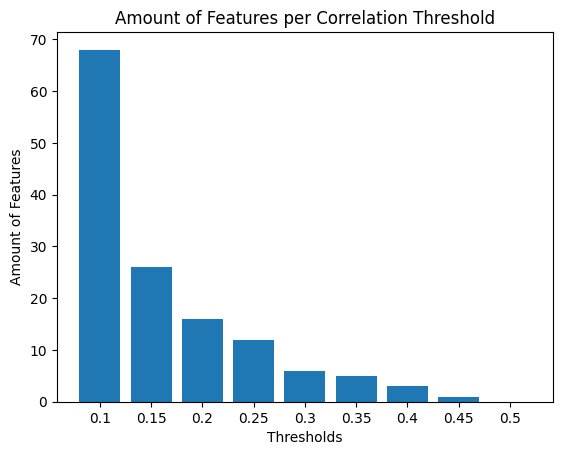

In [20]:
# graph of the amount of features we can get with different correlation thresholds

amounts = []
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    filtCorrs = []
    for i in range(len(correlations)):
        if correlations[i] > t or correlations[i] < t*-1:
            filtCorrs.append((codes[i], correlations[i]))
    amounts.append(len(filtCorrs))


plt.bar(list(map(str, thresholds)), amounts, label = thresholds)
plt.title('Amount of Features per Correlation Threshold')
plt.xlabel('Thresholds')
plt.ylabel('Amount of Features')

In [21]:
codeDict = {
    "DIQ070": ("Diabetes", "Take diabetic pills to lower blood sugar"),
    "BAXMSTAT": ("Balance", "MRT exam status"),
    "BAX5STAT": ("Balance", "Eligibility for Condition 5"),
    "BAARFC11": ("Balance", "MRT cond. 1, trial 1, reason stopped"),
    "BAXPF12": ("Balance", "MRT cond. 1, trial 2, eyes open"),
    "BAXTC12": ("Balance", "MRT cond. 1, trial 2, time"),
    "BAARFC12": ("Balance", "MRT cond. 1, trial 2, reason stopped"),
    "BAXPF22": ("Balance", "MRT cond. 2, trial 2, eyes closed"),
    "BAXTC22": ("Balance", "MRT cond. 2, trial 2, time"),
    "BAARFC31": ("Balance", "MRT cond. 3, trial 1, reason stopped"),
    "BAXTC32": ("Balance", "MRT cond. 3, trial 2, time"),
    "BAARFC32": ("Balance", "MRT cond. 3, trial 2, reason stopped"),
    "BAXTC41": ("Balance", "MRT cond. 4, trial 1, time"),
    "BAXTC42": ("Balance", "MRT cond. 4, trial 2, time"),
    "BMXWT": ("Body Measures", "Weight (kg)"),
    "BMIHT": ("Body Measures", "Standing Height Comment"),
    "BMXBMI": ("Body Measures", "Body Mass Index (kg/m**2)"),
    "BMXARMC": ("Body Measures", "Arm Circumference (cm)"),
    "BMXWAIST": ("Body Measures", "Waist Circumference (cm)"),
    "BPQ020": ("Blood Pressure & Cholesterol", "Ever told you had high blood pressure"),
    "BPQ080": ("Blood Pressure & Cholesterol", "Doctor told you - high cholesterol level"),
    "BPQ101D": ("Blood Pressure & Cholesterol", "Taking meds to lower blood cholesterol?"),
    "BPAOCSZ": ("Blood Pressure - Oscillometric Measurements", "Coded cuff size - oscillometric"),
    "BPXOSY1": ("Blood Pressure - Oscillometric Measurements", "Systolic - 1st oscillometric reading"),
    "BPXOSY2": ("Blood Pressure - Oscillometric Measurements", "Systolic - 2nd oscillometric reading"),
    "BPXOSY3": ("Blood Pressure - Oscillometric Measurements", "Systolic - 3rd oscillometric reading"),
    "LBXRDW": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Red cell distribution width (%)"),
    "RIDAGEYR": ("Demographic Variables and Sample Weights", "Age in years at screening"),
    "DMDEDUC2": ("Demographic Variables and Sample Weights", "Education level - Adults 20+"),
    "DMDHHSIZ": ("Demographic Variables and Sample Weights", "Total number of people in the Household"),
    "PHACOFHR": ("Fasting Questionnaire", "Coffee/tea dast time (hours)"),
    "PHACOFMN": ("Fasting Questionnaire", "Coffee/tea fast time (minutes)"),
    "PHAALCMN": ("Fasting Questionnaire", "Alcohol fast time (minutes)"),
    "LBXFER": ("Ferritin", "Ferritin(ng/mL)"),
    "LBDFERSI": ("Ferritin", "Ferritin(mewg/L)"),
    "FNQ041": ("Functioning", "Difficulty hearing even w/ hearing aids"),
    "FNQ440": ("Functioning", "Difficulty walking or climbing steps"),
    "FNQ490": ("Functioning", "Difficulty using hands and fingers"),
    "FNDADI": ("Functioning", "WG-SS Disability Indicator 18+"),
    "FNDADEDI": ("Functioning", "WG-SS Enhanced Disability Indicator 18+"),
    "LBXSF6SI": ("Serum Folate Forms - Total & Individual - Serum", "Mefox oxidation product (nmol/L)"),
    "LBXGH": ("Glycohemoglobin", "Glycohemoglobin (%)"),
    "LBXGLU": ("Plasma Fasting Glucose", "Fasting Glucose (mg/dL)"),
    "LBDGLUSI": ("Plasma Fasting Glucose", "Fasting Glucose (mmol/L)"),
    "HUQ010": ("Hospital Utilization & Access to Care", "General health condition"),
    "LBXIN": ("Insulin", "Insulin (uU/mL)"),
    "LBDINSI": ("Insulin", "Insulin (pmol/L)"),
    "KIQ005": ("Kidney Conditions - Urology", "How often have urinary leakage"),
    "KIQ052": ("Kidney Conditions - Urology", "How much were daily activities affected"),
    "KIQ481": ("Kidney Conditions - Urology", "How many times wake up and urinate?"),
    "LUARXIN": ("Liver Ultrasound Transient Elastography", "Reason ineligible"),
    "LUXSMED": ("Liver Ultrasound Transient Elastography", "Median stiffness (E), kilopascals (kPa)"),
    "LUXCAOM": ("Liver Ultrasound Transient Elastography", "Median CAP, decibels per meter (dB/m)"),
    "OCD150": ("Occupation", "Type of work done last week"),
    "OHQ845": ("Occupation", "Rate the health of your teeth and gums"),
    "RHQ031": ("Reproductive Health", "Had regular periods in past 12 months"),
    "RHQ078": ("Reproductive Health", "Ever treated for a pelvic infection/PID"),
    "RHD280": ("Reproductive Health", "Had a hysterectomy?"),
    "RXQ510": ("Preventive Aspirin Use", "Dr told to take daily low-dose aspirin?"),
    "RXQ033": ("Prescription Medications", "Taken prescription medicine, past month"),
    "RXQ050": ("Prescription Medications", "Number of prescription medicines taken"),
    "SMQ740": ("Smoking - Recent Tobacco Use", "# days smoked pipe over last 5 days"),
    "SMQ690D": ("Smoking - Recent Tobacco Use", "Used last 5 days - Chewing tobacco"), 
    "LBDAMHLC": ("Sex Steroid Hormone Panel - Serum", "Anti-Mullerian hormone Comment Code"),
    "LBXDHE": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewg/dL)"),
    "LBDDHESI": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewmol/L)")
}

# Regressions

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Use the dataset with your identified correlated features
df = pd.read_csv('all_data.csv')

# Define target variable (1 for diabetes, 2 for no diabetes)
# We'll convert it to a binary format (0 for no diabetes, 1 for diabetes)
df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)  # 1=Yes, 2=No in original data

# Select features with correlation > 0.2 (or use your filtCorrs list)
# Let's pick a subset of meaningful features based on your correlation analysis
selected_features = [
    'BMXBMI',            # Body Mass Index
    'BMXWAIST',          # Waist Circumference
    'BPQ020',            # High blood pressure history
    'RIDAGEYR',          # Age in years
    'LBXGH',             # Glycohemoglobin
    'LBXGLU',            # Fasting Glucose
    'LBXIN'              # Insulin
]

# Display the selected dataset
print("Selected features shape:", df_ml[selected_features + ['diabetes']].shape)
df_ml[selected_features + ['diabetes']].head()

Selected features shape: (11452, 8)


,BMXBMI,BMXWAIST,BPQ020,RIDAGEYR,LBXGH,LBXGLU,LBXIN,diabetes
0,27.0,98.3,1.0,43.0,5.6,113.0,15.53,0
1,33.5,114.7,1.0,66.0,5.6,99.0,19.91,0
2,29.7,93.5,2.0,44.0,6.2,156.0,16.33,1
3,23.8,70.4,NaN,5.0,NaN,NaN,NaN,0
4,NaN,NaN,NaN,2.0,NaN,NaN,NaN,0


Initial data shape: (11452, 8)

Missing values by column:
BMXBMI      3212
BMXWAIST    3484
BPQ020      3229
RIDAGEYR       0
LBXGH       4960
LBXGLU      7910
LBXIN       8061
diabetes       0
dtype: int64
After removing rows with too many missing values: (6768, 8)


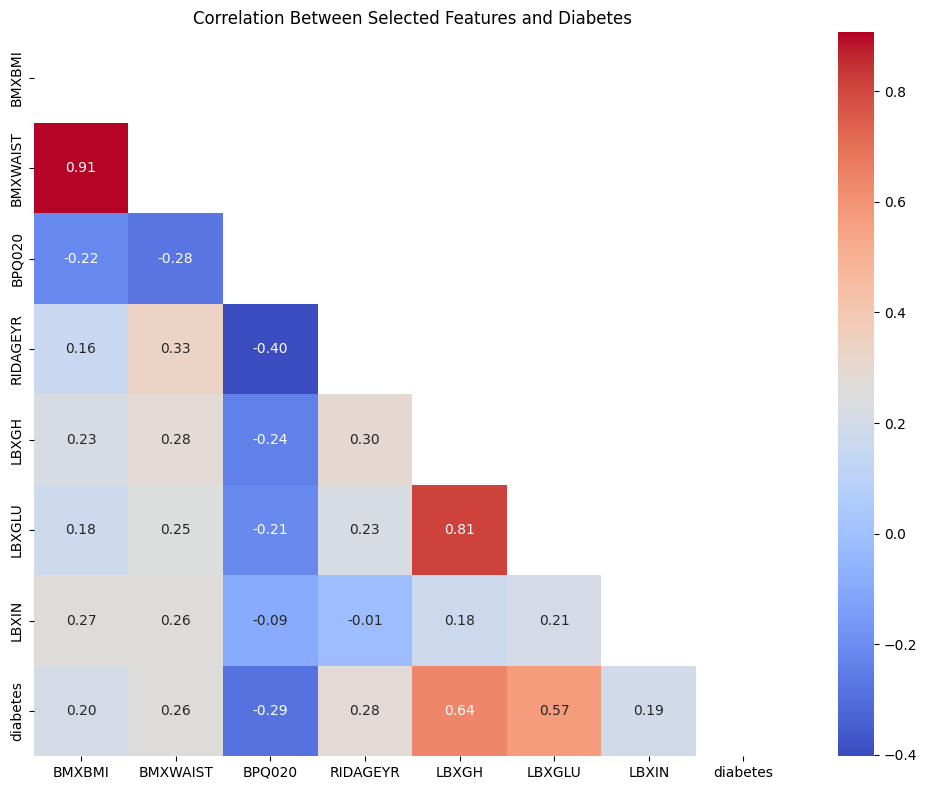

In [24]:
# Handling missing values and preprocessing
df_clean = df_ml[selected_features + ['diabetes']].copy()
print(f"Initial data shape: {df_clean.shape}")

# Check missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values by column:")
print(missing_values)

# Drop rows where too many features are missing (you may adjust this)
df_clean = df_clean.dropna(thresh=len(selected_features) // 2 + 2)  # Keep rows with at least half of features + target
print(f"After removing rows with too many missing values: {df_clean.shape}")

# Plot correlations of selected features
plt.figure(figsize=(10, 8))
corr = df_clean[selected_features + ['diabetes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Between Selected Features and Diabetes')
plt.tight_layout()
plt.show()

In [25]:
# Split the data
X = df_clean[selected_features]
y = df_clean['diabetes']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric columns (scaling)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create preprocessing and modeling pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['BMXBMI', 'BMXWAIST', 'BPQ020', 'RIDAGEYR', 'LBXGH', 'LBXGLU', 'LBXIN'], dtype='object'))])),
                ('classifier', LogisticRegression(random_state=42))])

Classification Accuracy: 0.9453

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1202
           1       0.90      0.58      0.70       152

    accuracy                           0.95      1354
   macro avg       0.92      0.79      0.84      1354
weighted avg       0.94      0.95      0.94      1354



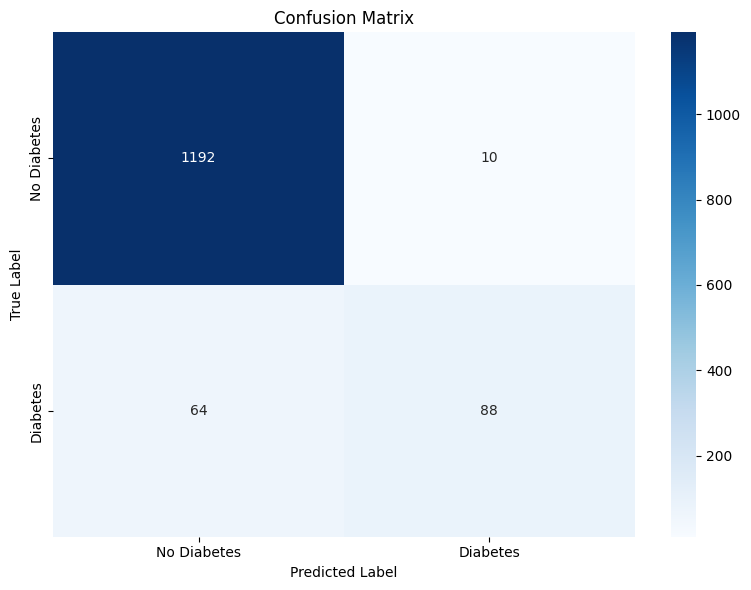

In [26]:
# Evaluate classification performance
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [27]:
# Try additional classifier models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
}

# Compare models
results = {}
for name, classifier in classifiers.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores
    
    print(f"{name} - Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} - Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()

Logistic Regression - Cross-validation accuracy: 0.9366 ± 0.0050
Logistic Regression - Test accuracy: 0.9453

Random Forest - Cross-validation accuracy: 0.9397 ± 0.0081
Random Forest - Test accuracy: 0.9557



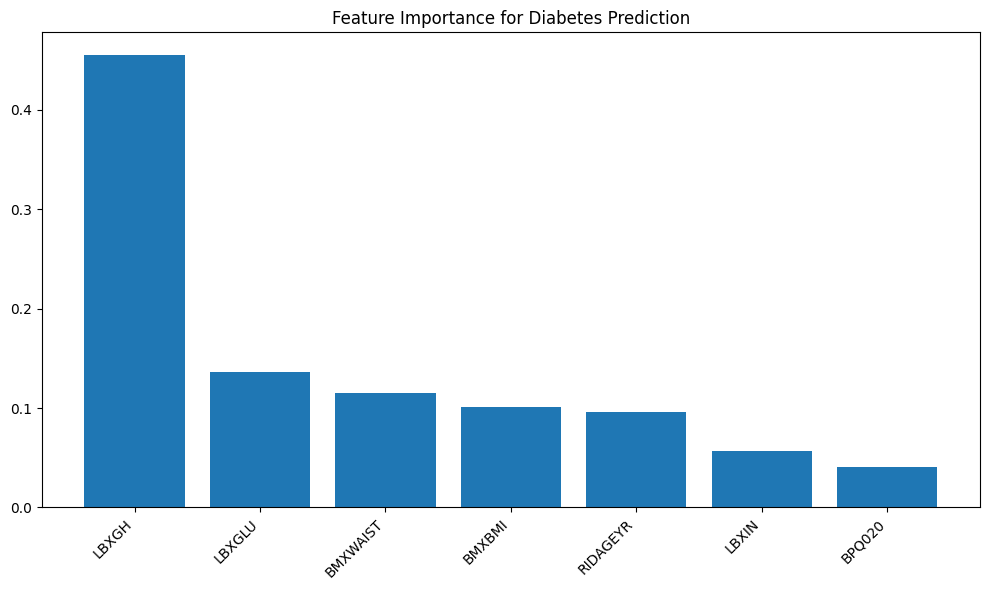

Feature Importance:
LBXGH: 0.4551
LBXGLU: 0.1361
BMXWAIST: 0.1152
BMXBMI: 0.1006
RIDAGEYR: 0.0955
LBXIN: 0.0569
BPQ020: 0.0405


In [28]:
# Feature importance analysis with Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_model.fit(X_train, y_train)

# Extract feature importance
rf_classifier = rf_model.named_steps['classifier']
feature_names = selected_features
feature_importance = rf_classifier.feature_importances_

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importance for Diabetes Prediction')
plt.bar(range(len(feature_importance)), feature_importance[indices], align='center')
plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print feature importance
print("Feature Importance:")
for i in indices:
    feature = feature_names[i]
    importance = feature_importance[i]
    print(f"{feature}: {importance:.4f}")

### Regression to predict Glycohemoglobin levels (LBXGH)

Glycohemoglobin (LBXGH) Prediction:
Mean Squared Error: 0.4861
R^2 Score: 0.5303


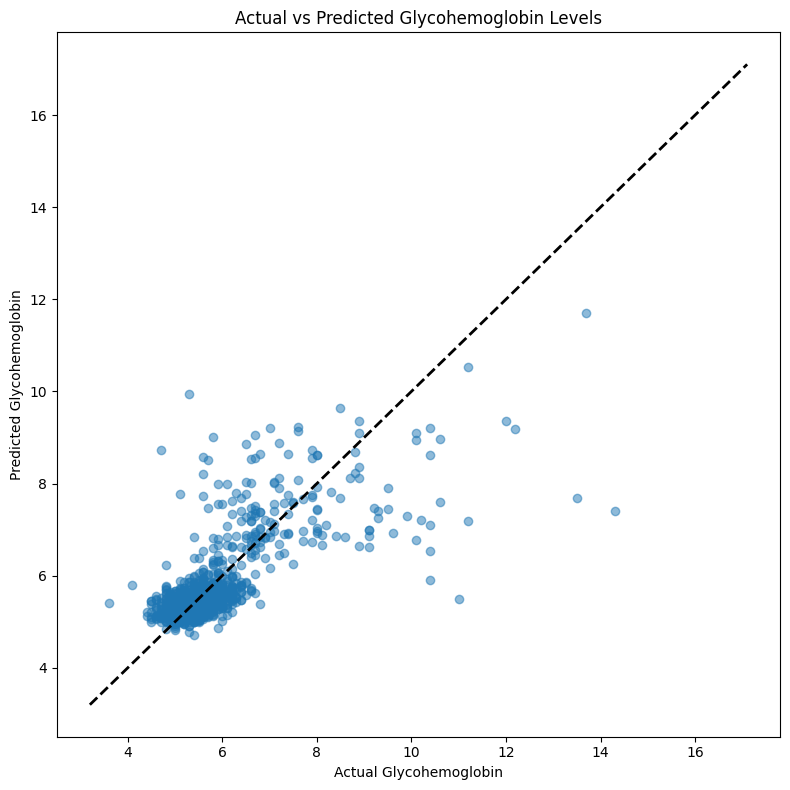

In [29]:
# Define new target
if 'LBXGH' in df_ml.columns:
    # Filter out any missing values in the target
    df_reg = df_ml.dropna(subset=['LBXGH'])
    
    # Choose predictors (removing LBXGH from the features list)
    reg_features = [f for f in selected_features if f != 'LBXGH']
    
    # Add diabetes as a feature
    reg_features.append('diabetes')
    
    # Define X and y for regression
    X_reg = df_reg[reg_features]
    y_reg = df_reg['LBXGH']
    
    # Split data
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    
    # Create a new preprocessor for regression using the columns in reg_features
    numeric_transformer_reg = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    reg_preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_reg, reg_features)
        ])
    
    # Create regression pipeline
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    # Train regression model
    reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate regression performance
    y_reg_pred = reg_pipeline.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_reg_pred)
    r2 = r2_score(y_reg_test, y_reg_pred)
    
    print(f"Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    
    # Plot actual vs predicted values
    plt.figure(figsize=(8, 8))
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Actual vs Predicted Glycohemoglobin Levels')
    plt.tight_layout()
    plt.show()


Linear Regression for Glycohemoglobin (LBXGH) Prediction:
Mean Squared Error: 0.5123
R^2 Score: 0.5050

Model Comparison:
Random Forest R^2: 0.5303
Linear Regression R^2: 0.5050


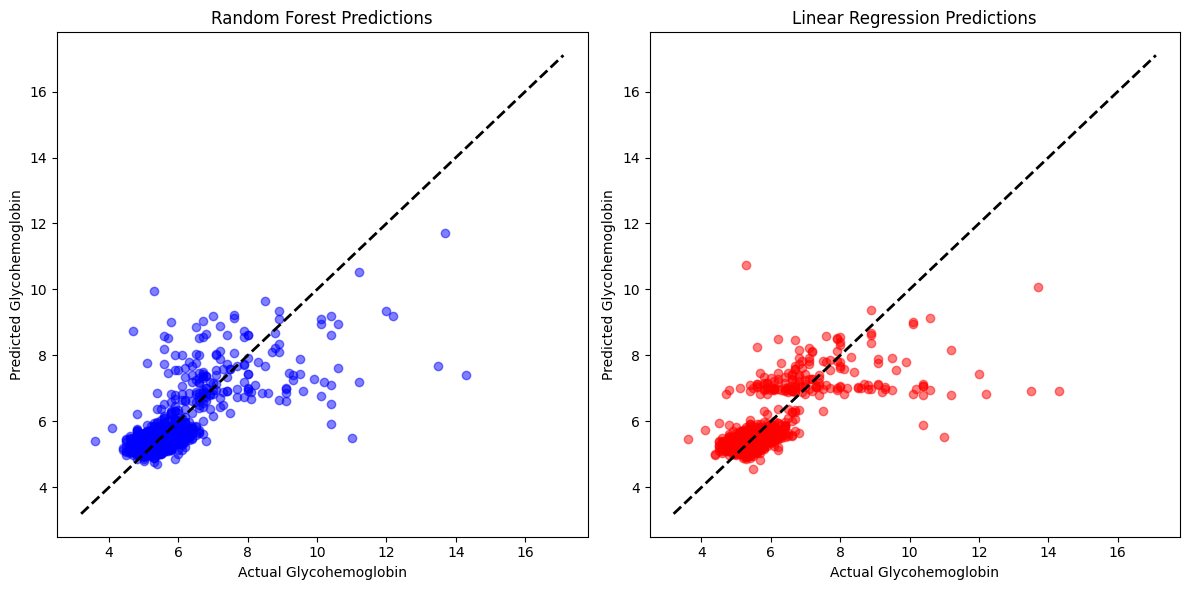

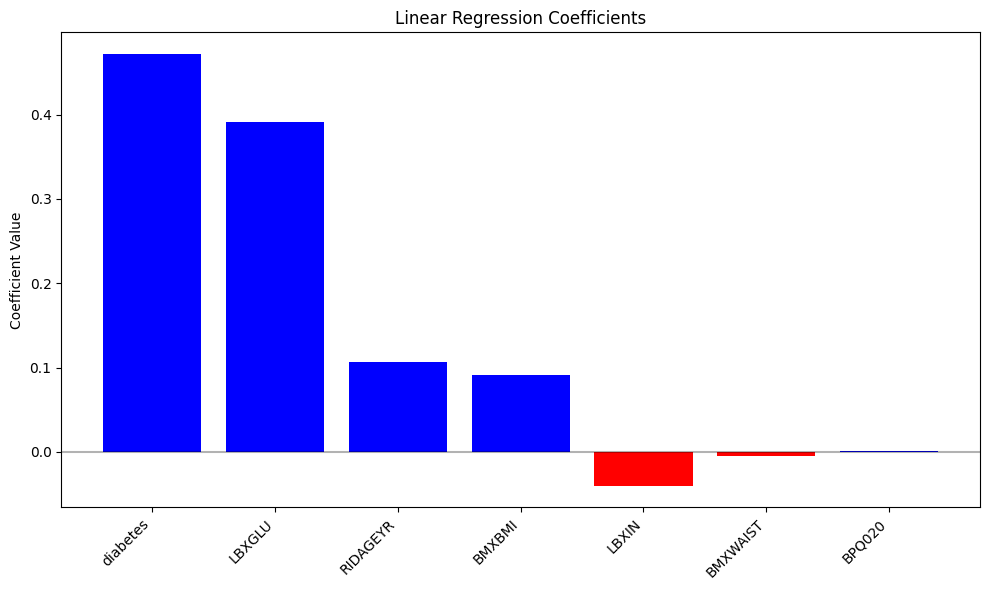


Linear Regression Coefficients:
BMXBMI: 0.0915
BMXWAIST: -0.0054
BPQ020: 0.0004
RIDAGEYR: 0.1062
LBXGLU: 0.3916
LBXIN: -0.0403
diabetes: 0.4720

Updated Model Comparison:
Random Forest R^2: 0.5303
Linear Regression R^2: 0.5050
Difference: 0.0252


In [30]:
# Add Linear Regression for Glycohemoglobin prediction
if 'LBXGH' in df_ml.columns:
    # Create a linear regression pipeline
    linear_reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', LinearRegression())
    ])
    
    # Train the linear regression model
    linear_reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate linear regression performance
    linear_y_pred = linear_reg_pipeline.predict(X_reg_test)
    linear_mse = mean_squared_error(y_reg_test, linear_y_pred)
    linear_r2 = r2_score(y_reg_test, linear_y_pred)
    
    print("\nLinear Regression for Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {linear_mse:.4f}")
    print(f"R^2 Score: {linear_r2:.4f}")
    
    # Compare with Random Forest Regressor
    print("\nModel Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    
    # Visualize predictions from both models
    plt.figure(figsize=(12, 6))
    
    # Random Forest predictions
    plt.subplot(1, 2, 1)
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5, color='blue')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Random Forest Predictions')
    
    # Linear Regression predictions
    plt.subplot(1, 2, 2)
    plt.scatter(y_reg_test, linear_y_pred, alpha=0.5, color='red')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Linear Regression Predictions')
    
    plt.tight_layout()
    plt.show()
    
    # Plot feature coefficients for linear model
    if hasattr(linear_reg_pipeline.named_steps['regressor'], 'coef_'):
        # Get coefficients
        coefficients = linear_reg_pipeline.named_steps['regressor'].coef_
        
        # Create a DataFrame for visualization
        coef_df = pd.DataFrame({
            'Feature': reg_features,
            'Coefficient': coefficients
        })
        
        # Sort by absolute coefficient value
        coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
        coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
        
        # Plot
        plt.figure(figsize=(10, 6))
        colors = ['red' if c < 0 else 'blue' for c in coef_df['Coefficient']]
        plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors)
        plt.xticks(rotation=45, ha='right')
        plt.title('Linear Regression Coefficients')
        plt.ylabel('Coefficient Value')
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Print feature coefficients with descriptions when available
        print("\nLinear Regression Coefficients:")
        for feature, coef in zip(reg_features, coefficients):
            print(f"{feature}: {coef:.4f}")
    
    # Update the model summary cell to include linear regression
    print("\nUpdated Model Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    print(f"Difference: {abs(r2 - linear_r2):.4f}")

In [31]:
# Model Summary
print(f"1. Classification Models (Diabetes Prediction):")
print(f"   - Random Forest:       {results['Random Forest'].mean():.4f} ± {results['Random Forest'].std():.4f}")
print(f"   - Logistic Regression: {results['Logistic Regression'].mean():.4f} ± {results['Logistic Regression'].std():.4f}")
print(f"   - Best model accuracy:  {max([results[model].mean() for model in results]):.4f}")

print(f"\n2. Top features for diabetes prediction (by importance):")
for i in indices[:3]:
    feature = feature_names[i]
    print(f"   - {feature}: {feature_importance[i]:.4f}")

print(f"\n3. Classification Performance:")
print(f"   - Precision for diabetes detection: {classification_report(y_test, y_pred).split()[11]}")
print(f"   - Recall for diabetes detection:    {classification_report(y_test, y_pred).split()[12]}")
print(f"   - F1-score for diabetes detection:  {classification_report(y_test, y_pred).split()[13]}")

if 'LBXGH' in df_ml.columns:
    print(f"\n4. Glycohemoglobin Regression Models:")
    print(f"   - Random Forest R^2:       {r2:.4f}")
    print(f"   - Linear Regression R^2:   {linear_r2:.4f}")
    print(f"   - Mean Squared Error:     {mse:.4f}")

1. Classification Models (Diabetes Prediction):
   - Random Forest:       0.9397 ± 0.0081
   - Logistic Regression: 0.9366 ± 0.0050
   - Best model accuracy:  0.9397

2. Top features for diabetes prediction (by importance):
   - LBXGH: 0.4551
   - LBXGLU: 0.1361
   - BMXWAIST: 0.1152

3. Classification Performance:
   - Precision for diabetes detection: 0.70
   - Recall for diabetes detection:    0.78
   - F1-score for diabetes detection:  152

4. Glycohemoglobin Regression Models:
   - Random Forest R^2:       0.5303
   - Linear Regression R^2:   0.5050
   - Mean Squared Error:     0.4861
